---
title: "Seaborn Datasets"
subtitle: "DS 2023 | Communicating with Data"
___

## Overview

Use this to explore Seaborn's data sets.

For each data set, create a page that explores its various transformational possibilities.

Also include these metadata:

- name
- provenance
- format
- data dictionary
- use cases

## Data, data shapes, and transformations

:::{note}
Pull this out into a separate page that precedes this one.
:::


**Identifers vs Measurements**

- _Identifers_ are nominal data that name, classify, or label observations. Functionally, these can be used to group data for aggregration and conditional computations. Thes are logical facts that are often, but not always, known before the collection of data.

- _Measurements_ are the results from an instrument that measures. These are empirical facts that come from experiments and experience. Measurements are often numeric, but also may be categorical, as in the case of survey data.

- _Unstructured data_ constitute a third category, accounting data that has not been converted into countable form. This is usually text or image data associated with an observation.

**Data shapes**

- Narrow form (aka Long)
- Wide form
- Tidy form is long form (but sometimes called wide)
- Aggregate multi-feature

**Indexes and Keys**

- Columns are indexes
- Indexes must be unique
- All data frames have an index, but some indexes are key indexes -- they are uniquie combinations of identifying features
- Columns are indexes

**Data transforms**

- Aggregation through Split-Apply-Combine
- Pivoting and feature domain projection
- Concatenating
- Melting

## All datasets

https://github.com/mwaskom/seaborn-data

In [1021]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact
from IPython.display import display, HTML

In [1022]:
datasets = sns.get_dataset_names()

In [260]:
@interact(dataset=datasets)
def inspect_dataset(dataset):
    df = sns.load_dataset(dataset)
    display(df.info())
    display(df.sample(10))

interactive(children=(Dropdown(description='dataset', options=('anagrams', 'anscombe', 'attention', 'brain_net…

## Brain networks

**Metadata**
- name: Brain Networks
- description: Contains resting-state fMRI connectivity data for $92$ human subjects, measuring the correlations in brain activity across $62$ distinct cortical regions. 

**Format notes**
- The data are intended to be imported using the `header` and `index` arguments to `sns.load_dataset()` where `header=[0, 1, 2]` and `index_col=0`. Importing without these arguments forces Pandas to convert the `network` values to decimals in order to satisfy the uniqueness constraint on columns.
- Data are in **wide** format.

**Data dictionary**

Because the data are in wide format, the features of the data set are a projection of the domain of brain region mapping.

`network`: This represents the broad functional brain network that a specific region belongs to (labeled as integers, such as Network 1, Network 5, etc.). 

Brain regions inside the same functional network sync up their activity even when a person is just resting in the scanner.

`node`: This indicates the specific anatomical region or structural hub within that network. 

If a "network" is an entire subway line, a "node" is an individual train station on that line.

`hemi`: This stands for hemisphere, where `lh` stands for Left Hemisphere and `rh` Right Hemisphere.

The columns are stored using a multi-index representing the Network number (e.g., visual, motor, default mode) and the Region ID.

**Structure**

- Rows: $92$ unique scans.
- Columns: $62$ unique brain regions.
- Cells: each cell contains an fMRI Blood-Oxygen-Level Dependent (BOLD) signal value. These values represent statistical summaries of localized neural activity over time.

**Use cases** 

- structured covariance
- hierarchical clustering


In [983]:
brain = sns.load_dataset('brain_networks')
brain.info()
brain.head()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 63 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   network  922 non-null    str  
 1   1        922 non-null    str  
 2   1.1      922 non-null    str  
 3   2        922 non-null    str  
 4   2.1      922 non-null    str  
 5   3        922 non-null    str  
 6   3.1      922 non-null    str  
 7   4        922 non-null    str  
 8   4.1      922 non-null    str  
 9   5        922 non-null    str  
 10  5.1      922 non-null    str  
 11  6        922 non-null    str  
 12  6.1      922 non-null    str  
 13  6.2      922 non-null    str  
 14  6.3      922 non-null    str  
 15  7        922 non-null    str  
 16  7.1      922 non-null    str  
 17  7.2      922 non-null    str  
 18  7.3      922 non-null    str  
 19  7.4      922 non-null    str  
 20  7.5      922 non-null    str  
 21  8        922 non-null    str  
 22  8.1      922 non-null    str  
 23  8

,network,1,1.1,2,2.1,3,3.1,4,4.1,5,...,16.5,16.6,16.7,17,17.1,17.2,17.3,17.4,17.5,17.6
0,node,1,1,1,1,1,1,1,1,1,...,3,4,4,1,1,2,2,3,3,4
1,hemi,lh,rh,lh,rh,lh,rh,lh,rh,lh,...,rh,lh,rh,lh,rh,lh,rh,lh,rh,lh
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,56.05574417114258,92.03103637695312,3.391575574874878,38.65968322753906,26.203819274902344,-49.71556854248047,47.4610366821289,26.746612548828125,-35.898860931396484,...,0.6079040169715881,-70.27054595947266,77.36577606201172,-21.73455047607422,1.0282527208328247,7.7917842864990225,68.90372467041016,-10.520872116088867,120.49046325683594,-39.686431884765625
4,1,55.5472526550293,43.6900749206543,-65.49598693847656,-13.974522590637207,-28.27496337890625,-39.05012893676758,-1.2106596231460571,-19.012897491455078,19.568010330200195,...,57.49507141113281,-76.39321899414062,127.26136016845705,-13.035799026489258,46.3818244934082,-15.752449989318848,31.00033187866211,-39.607521057128906,24.76401138305664,-36.7710075378418


### Wide form with hierchical columns

:::{note}
This is an interesting table because it is both wide and tidy.
:::

In [984]:
brain = sns.load_dataset('brain_networks', header=[0, 1, 2], index_col=0)
brain.info()
brain.head()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 62 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   (1, 1, lh)   920 non-null    float64
 1   (1, 1, rh)   920 non-null    float64
 2   (2, 1, lh)   920 non-null    float64
 3   (2, 1, rh)   920 non-null    float64
 4   (3, 1, lh)   920 non-null    float64
 5   (3, 1, rh)   920 non-null    float64
 6   (4, 1, lh)   920 non-null    float64
 7   (4, 1, rh)   920 non-null    float64
 8   (5, 1, lh)   920 non-null    float64
 9   (5, 1, rh)   920 non-null    float64
 10  (6, 1, lh)   920 non-null    float64
 11  (6, 1, rh)   920 non-null    float64
 12  (6, 2, lh)   920 non-null    float64
 13  (6, 2, rh)   920 non-null    float64
 14  (7, 1, lh)   920 non-null    float64
 15  (7, 1, rh)   920 non-null    float64
 16  (7, 2, lh)   920 non-null    float64
 17  (7, 2, rh)   920 non-null    float64
 18  (7, 3, lh)   920 non-null    float64
 19  (7, 3, rh)   920 no

network          1                     2                     3             \
node             1                     1                     1              
hemi            lh         rh         lh         rh         lh         rh   
0        56.055744  92.031036   3.391576  38.659683  26.203819 -49.715569   
1        55.547253  43.690075 -65.495987 -13.974523 -28.274963 -39.050129   
2        60.997768  63.438793 -51.108582 -13.561346 -18.842947  -1.214659   
3        18.514868  12.657158 -34.576603 -32.665958  -7.420454  17.119448   
4        -2.527392 -63.104668 -13.814151 -15.837989 -45.216927   3.483550   

network          4                     5             ...         16  \
node             1                     1             ...          3   
hemi            lh         rh         lh         rh  ...         rh   
0        47.461037  26.746613 -35.898861  -1.889181  ...   0.607904   
1        -1.210660 -19.012897  19.568010  15.902983  ...  57.495071   
2       -65.575806 -85.777428  19.247454  37.209419  ...  28.317369   
3       -41.800869 -58.610184  32.896915  11.199619  ...  71.439629   
4       -62.613335 -49.076508  18.396759   3.219077  ...  95.597565   

network                                17                                   \
node             4                      1                     2              
hemi            lh          rh         lh         rh         lh         rh   
0       -70.270546   77.365776 -21.734550   1.028253   7.791784  68.903725   
1       -76.393219  127.261360 -13.035799  46.381824 -15.752450  31.000332   
2         9.063977   45.493263  26.033442  34.212200   1.326110 -22.580757   
3        65.842979  -10.697547  55.297466   4.255006  -2.420144  12.098393   
4        50.960453  -23.197300  43.067562  52.219875  28.232882 -11.719750   

network                                    
node             3                      4  
hemi            lh          rh         lh  
0       -10.520872  120.490463 -39.686432  
1       -39.607521   24.764011 -36.771008  
2        12.985169  -75.027451   6.434262  
3       -15.819172  -37.361431  -4.650954  
4         5.453649    5.169828  87.809135  

[5 rows x 62 columns]

### Wide with flat columns

In [731]:
brain1 = brain.copy()
brain1.columns = ['_'.join(col) for col in brain.columns]
brain1

,1_1_lh,1_1_rh,2_1_lh,2_1_rh,3_1_lh,3_1_rh,4_1_lh,4_1_rh,5_1_lh,5_1_rh,...,16_3_rh,16_4_lh,16_4_rh,17_1_lh,17_1_rh,17_2_lh,17_2_rh,17_3_lh,17_3_rh,17_4_lh
0,56.055744,92.031036,3.391576,38.659683,26.203819,-49.715569,47.461037,26.746613,-35.898861,-1.889181,...,0.607904,-70.270546,77.365776,-21.734550,1.028253,7.791784,68.903725,-10.520872,120.490463,-39.686432
1,55.547253,43.690075,-65.495987,-13.974523,-28.274963,-39.050129,-1.210660,-19.012897,19.568010,15.902983,...,57.495071,-76.393219,127.261360,-13.035799,46.381824,-15.752450,31.000332,-39.607521,24.764011,-36.771008
2,60.997768,63.438793,-51.108582,-13.561346,-18.842947,-1.214659,-65.575806,-85.777428,19.247454,37.209419,...,28.317369,9.063977,45.493263,26.033442,34.212200,1.326110,-22.580757,12.985169,-75.027451,6.434262
3,18.514868,12.657158,-34.576603,-32.665958,-7.420454,17.119448,-41.800869,-58.610184,32.896915,11.199619,...,71.439629,65.842979,-10.697547,55.297466,4.255006,-2.420144,12.098393,-15.819172,-37.361431,-4.650954
4,-2.527392,-63.104668,-13.814151,-15.837989,-45.216927,3.483550,-62.613335,-49.076508,18.396759,3.219077,...,95.597565,50.960453,-23.197300,43.067562,52.219875,28.232882,-11.719750,5.453649,5.169828,87.809135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,-7.429513,-4.813219,-3.670537,1.442261,-19.680431,-29.109356,-3.376562,-8.764893,0.017912,-25.305094,...,58.285793,68.557411,22.833048,76.179489,51.934669,-6.614513,-6.690762,22.893030,48.274380,76.228455
916,-33.554138,-38.605621,-25.664803,-30.252352,5.562785,20.182186,17.911247,24.653582,-32.935612,-21.783203,...,59.864819,23.004578,7.657463,50.962399,13.696922,63.503616,57.401176,24.974548,51.972153,64.538788
917,-78.539566,-74.197189,-54.041595,-39.970291,-14.277059,-30.606461,60.628521,62.027023,-32.800556,-37.021500,...,68.767868,49.664017,64.551498,43.800747,8.144480,47.281460,70.499649,66.994400,81.539246,64.969772
918,-103.235825,-98.744286,-40.109543,-44.907734,12.109148,1.621340,33.765560,55.356071,-14.330512,-17.224781,...,103.155251,106.454849,9.046827,46.674419,40.954796,0.877180,37.577152,20.517746,3.124434,56.718388


### Long form

In [732]:
brain2 = brain.unstack().to_frame('bold_signal')
brain2.index.names = list(brain.columns.names) + ['scan_id']
brain2 = brain2.reset_index()
brain2 = brain2[['scan_id', 'network', 'node', 'hemi', 'bold_signal']]
brain2

,scan_id,network,node,hemi,bold_signal
0,0,1,1,lh,56.055744
1,1,1,1,lh,55.547253
2,2,1,1,lh,60.997768
3,3,1,1,lh,18.514868
4,4,1,1,lh,-2.527392
...,...,...,...,...,...
57035,915,17,4,lh,76.228455
57036,916,17,4,lh,64.538788
57037,917,17,4,lh,64.969772
57038,918,17,4,lh,56.718388


### Long form with key index

This format distinguishes structure from measurement.

In [468]:
brain3 = brain2.set_index(['scan_id', 'network', 'node', 'hemi']).sort_index()
brain3

bold_signal
scan_id network node hemi             
0       1       1    lh      56.055744
                     rh      92.031036
        10      1    lh      -8.327313
                     rh      15.077152
        11      1    lh     -10.356273
...                                ...
919     8       2    rh     -11.252352
                3    lh     -12.368189
                     rh     -19.687576
        9       1    lh       1.073356
                     rh      29.314196

[57040 rows x 1 columns]

## Dow Jones

### Long form (tidy)

In [541]:
dowjones = sns.load_dataset('dowjones')
dowjones

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12


### Long form with key index

In [543]:
dowjones2 = dowjones.copy()
dowjones2['Date'] = pd.to_datetime(dowjones.Date)
dowjones2 = dowjones2.set_index('Date')
dowjones2

,Price
Date,
1914-12-01,55.00
1915-01-01,56.55
1915-02-01,56.00
1915-03-01,58.30
1915-04-01,66.45
...,...
1968-08-01,883.72
1968-09-01,922.80
1968-10-01,955.47


### Long form aggregated by year

In [568]:
dowjones3 = dowjones.groupby(dowjones2.index.year).Price.mean().to_frame('mean_price')
dowjones3.head()

,mean_price
Date,
1914,55.000000
1915,74.329167
1916,94.791667
1917,87.729167
1918,81.066667


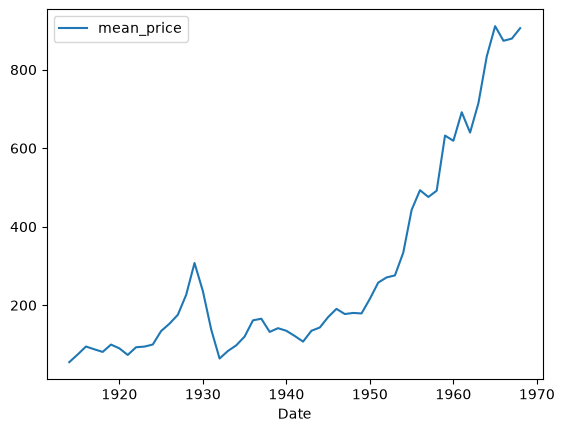

In [563]:
dowjones3.plot()
plt.show()

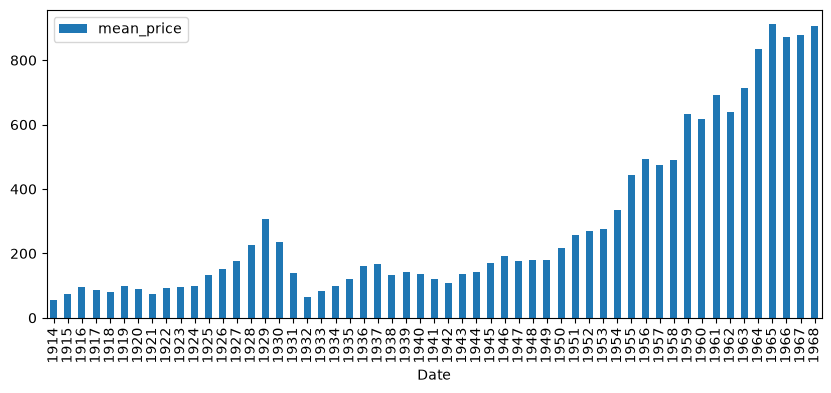

In [565]:
dowjones3.plot.bar(figsize=(10,4))
plt.show()

### Wide form aggregated by year and month

In [952]:
dowjones3 = dowjones.groupby([dowjones.Date.dt.year, dowjones.Date.dt.month]).Price.mean().to_frame('mean_price').unstack()
dowjones3.style.format(precision=2).background_gradient(axis=0)

## Sea ice

**Metadata**
- Name: Sea Ice Extent Dataset
- Description: A climate-monitoring resource that tracks the daily and monthly structural changes of polar ice caps from 1978 to the present day using satellite microwave data.
- Drovenance: maintained by the National Snow and Ice Data Center (NSIDC)
- Use cases: Can be used to teach time-series analysis, data cleaning, and statistical trend plotting.

**Data dictionary**
- `Date`: The date in `yyyy-mm-dd` format. Ranges from `1980-01-01` to `2019-12-31`.
- `Extent`: Area of ice measured in millions of square kilometers. Any 25km × 25km grid cell that has at least 15% ice concentration is counted.
  
**Observations**
- One row for each of $13175$ days.

**Use cases**

- heatmaps for vivid representation of aggregated data
- bar plots showing overall change in aggregated data
- line graphs showing seasonality and overall change

### Long form

In [267]:
seaice = sns.load_dataset('seaice')
seaice

,Date,Extent
0,1980-01-01,14.200
1,1980-01-03,14.302
2,1980-01-05,14.414
3,1980-01-07,14.518
4,1980-01-09,14.594
...,...,...
13170,2019-12-27,12.721
13171,2019-12-28,12.712
13172,2019-12-29,12.780
13173,2019-12-30,12.858


In [968]:
seaice.info()

<class 'pandas.DataFrame'>
RangeIndex: 13175 entries, 0 to 13174
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    13175 non-null  datetime64[us]
 1   Extent  13175 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 206.0 KB


### Long form with key index

In [268]:
seaice1 = seaice.set_index('Date')
seaice1

,Extent
Date,
1980-01-01,14.200
1980-01-03,14.302
1980-01-05,14.414
1980-01-07,14.518
1980-01-09,14.594
...,...
2019-12-27,12.721
2019-12-28,12.712
2019-12-29,12.780


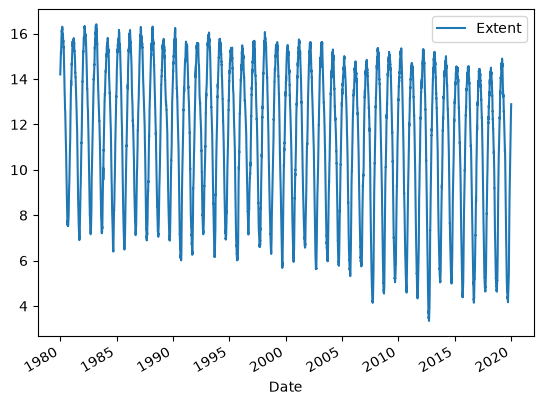

In [269]:
seaice1.plot()
plt.show()

### Long with expanded date as key index

In [270]:
seaice2 = seaice.copy()
seaice2['Date'] = pd.to_datetime(seaice['Date'])
seaice2['year'] = seaice2.Date.dt.year
seaice2['month'] = seaice2.Date.dt.month
seaice2['day'] = seaice2.Date.dt.day
seaice2 = seaice2.drop('Date', axis=1)
seaice2 = seaice2.set_index(['year','month','day']).sort_index()
seaice2

Extent
year month day        
1980 1     1    14.200
           3    14.302
           5    14.414
           7    14.518
           9    14.594
...                ...
2019 12    27   12.721
           28   12.712
           29   12.780
           30   12.858
           31   12.889

[13175 rows x 1 columns]

### Aggregated by year with key index

In [271]:
seaice3 = seaice2.groupby('year').mean()
seaice3

,Extent
year,
1980,12.334148
1981,12.135486
1982,12.439445
1983,12.335896
1984,11.912601
1985,11.986599
1986,12.208224
1987,11.397227
1988,12.093169


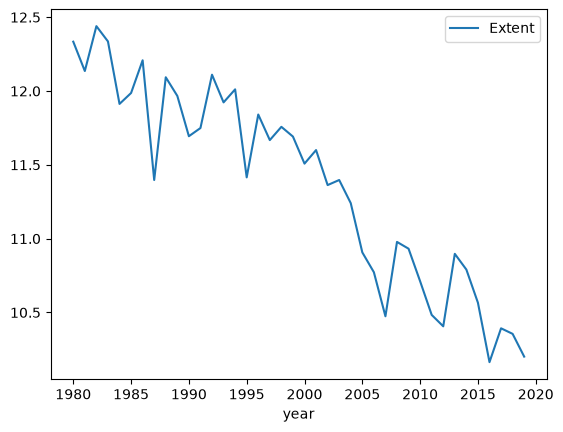

In [272]:
seaice3.plot()
plt.show()

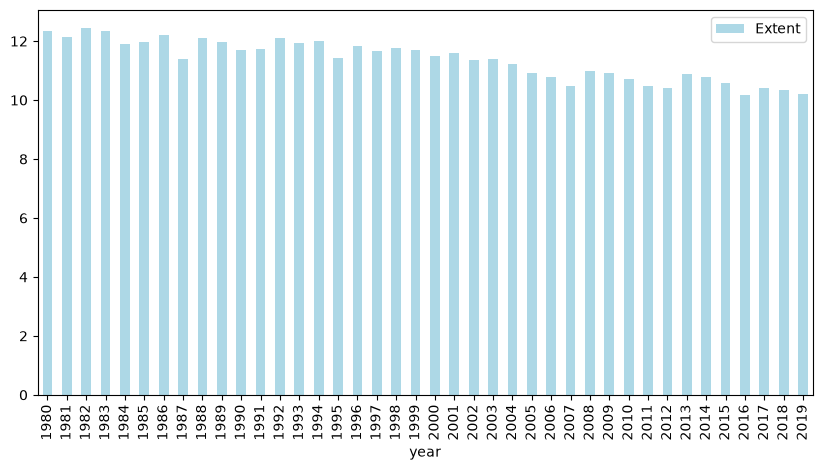

In [273]:
seaice3.plot.bar(figsize=(10,5), color='lightblue')
plt.show()

### Long form aggregated by year and month with key index

In [274]:
seaice4 = seaice2.groupby(['year','month']).Extent.mean().unstack()
seaice4

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1980,14.861875,15.955143,16.041313,15.429067,13.792600,12.204600,10.100062,7.984267,7.667067,9.182750,11.382867,13.592933
1981,14.909688,15.604071,15.631533,15.009933,13.801625,12.429733,10.271000,7.844313,7.138467,8.856267,10.929000,13.341125
1982,15.176733,15.973500,16.043875,15.466000,13.973200,12.476067,10.367062,8.139533,7.301733,9.421062,11.627467,13.641800
1983,14.942438,16.006143,16.085267,15.172067,13.491312,12.295667,10.570267,8.185875,7.394600,9.334067,11.461000,13.298438
1984,14.473267,15.298933,15.584200,15.014467,13.576688,12.151667,9.977533,7.771063,6.805200,8.560600,10.841533,12.989437
1985,14.724867,15.465714,15.885938,15.356533,14.073400,12.219067,9.744563,7.401867,6.697667,8.545938,11.024533,13.049933
1986,14.889625,15.784857,15.909467,15.058800,13.379563,11.975933,10.146467,7.979563,7.410667,9.483933,11.453267,13.222437
1987,14.969800,16.050143,15.815938,15.210867,13.742933,12.485667,10.332562,7.499905,7.278700,9.048774,11.224033,12.540500
1988,15.090474,15.583379,15.957226,15.123333,13.560871,11.943433,9.808677,7.891581,7.369000,9.135032,11.330833,13.625548


In [953]:
seaice4.style.format(precision=2).background_gradient(cmap='Reds_r', axis=None)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1980,14.86,15.96,16.04,15.43,13.79,12.20,10.10,7.98,7.67,9.18,11.38,13.59
1981,14.91,15.60,15.63,15.01,13.80,12.43,10.27,7.84,7.14,8.86,10.93,13.34
1982,15.18,15.97,16.04,15.47,13.97,12.48,10.37,8.14,7.30,9.42,11.63,13.64
1983,14.94,16.01,16.09,15.17,13.49,12.30,10.57,8.19,7.39,9.33,11.46,13.30
1984,14.47,15.30,15.58,15.01,13.58,12.15,9.98,7.77,6.81,8.56,10.84,12.99
1985,14.72,15.47,15.89,15.36,14.07,12.22,9.74,7.40,6.70,8.55,11.02,13.05
1986,14.89,15.78,15.91,15.06,13.38,11.98,10.15,7.98,7.41,9.48,11.45,13.22
1987,14.97,16.05,15.82,15.21,13.74,12.49,10.33,7.50,7.28,9.05,11.22,12.54
1988,15.09,15.58,15.96,15.12,13.56,11.94,9.81,7.89,7.37,9.14,11.33,13.63


In [471]:
# fig, ax = plt.subplots(figsize=(20,10))
# plt.imshow(seaice4.T, cmap='Reds_r')
# ax.set_xticks([i for i in range(seaice4.shape[0])])
# ax.set_xticklabels(seaice4.index)
# plt.show()

### Long form aggregated by year and month with key index

In [472]:
seaice5 = seaice4.stack().to_frame('Extent')
seaice5

Extent
year month           
1980 1      14.861875
     2      15.955143
     3      16.041313
     4      15.429067
     5      13.792600
...               ...
2019 8       5.026323
     9       4.363900
     10      5.734903
     11      9.352833
     12     11.903097

[480 rows x 1 columns]

## Health expectations

**Data dictionary**
- `Year`: The calendar year of the observation.
- `Country`: Country names, including USA, Canada, Japan, France, Germany, and Great Britain.
- `Spending_USD`: Mean healthcare spending per capita in US Dollars (USD).
- `Life_Expectancy`: Mean life expectancy at birth in years.

**Use cases**

Because the data contains both categorical elements (countries) and numeric timelines, it is highly flexible:

Line Plots: Track how life expectancy or spending has risen for a single country (like the USA) over the years.

Scatter Plots: Plot `Spending_USD` on the X-axis against `Life_Expectancy` on the Y-axis, adding c="Country" to see if higher spending directly correlates to longer life across different cultures.

Bar Plots: Compare the overall distribution of healthcare budgets or life outcomes across the different countries.

### Long form (tidy)

Since the data are already aggregated by Year and Country, this may not technically fall under the category of tidy.

In [520]:
healthexp = sns.load_dataset('healthexp')
healthexp

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


### Long form with key index

We separate out identity data from measurements.

In [367]:
healthexp1 = healthexp.set_index(['Year', 'Country'])
healthexp1

Spending_USD  Life_Expectancy
Year Country                                     
1970 Germany             252.311             70.6
     France              192.143             72.2
     Great Britain       123.993             71.9
     Japan               150.437             72.0
     USA                 326.961             70.9
...                          ...              ...
2020 Germany            6938.983             81.1
     France             5468.418             82.3
     Great Britain      5018.700             80.4
     Japan              4665.641             84.7
     USA               11859.179             77.0

[274 rows x 2 columns]

### Long form aggregated by Country

We drop out Year and get the mean values of each measurement.

In [362]:
healthexp2 = healthexp.groupby(['Country']).agg({'Life_Expectancy':'mean', 'Spending_USD':'sum'})
healthexp2

,Life_Expectancy,Spending_USD
Country,,
Canada,78.706818,118174.247
France,79.565714,106580.077
Germany,76.726000,133364.010
Great Britain,77.620930,87470.276
Japan,79.554902,94873.153
USA,75.843137,223817.097


### Long form aggregated by Year

We drop out Country and get the mean values of each measurement.

In [381]:
healthexp3 = healthexp.groupby(['Year']).agg({'Life_Expectancy':'mean', 'Spending_USD':'sum'})
healthexp3

,Life_Expectancy,Spending_USD
Year,,
1970,71.520000,1045.845
1971,71.920000,1267.656
1972,71.800000,919.851
1973,72.033333,1029.621
1974,72.400000,1189.876
1975,72.850000,1741.110
1976,73.325000,2077.011
1977,73.700000,1714.221
1978,73.866667,1930.918


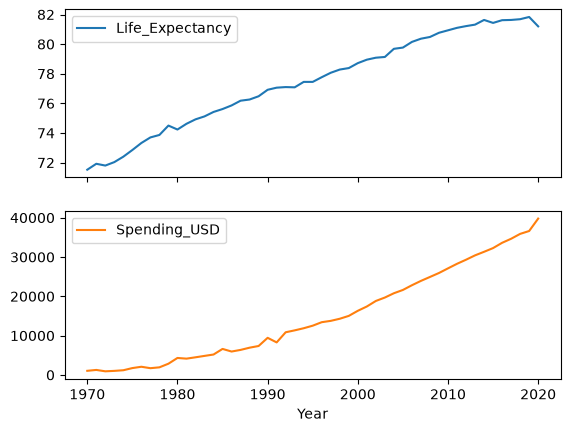

In [384]:
healthexp3.plot(subplots=True)
plt.show()

### Long form of Spending_USD

We represent the data for one measurement by projecting one index into column space.

In [385]:
healthexp3 = healthexp1.Spending_USD.unstack()
healthexp3

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,192.143,252.311,123.993,150.437,326.961
1971,313.391,NaN,298.251,134.172,163.854,357.988
1972,NaN,NaN,337.364,NaN,185.390,397.097
1973,NaN,NaN,384.541,NaN,205.778,439.302
1974,NaN,NaN,452.744,NaN,242.018,495.114
1975,NaN,363.610,532.481,NaN,284.269,560.750
1976,543.337,NaN,591.098,NaN,303.725,638.851
1977,NaN,NaN,647.352,NaN,340.628,726.241
1978,NaN,NaN,729.457,NaN,392.577,808.884


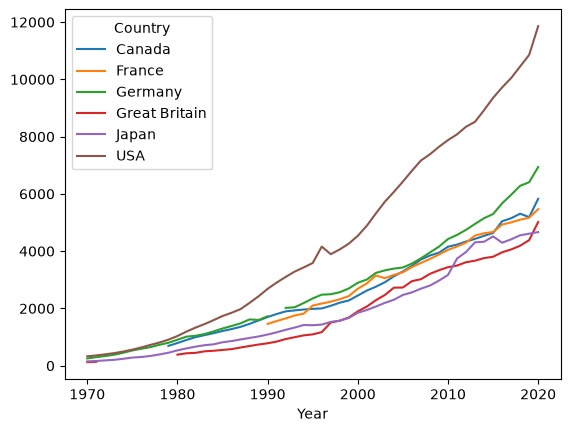

In [387]:
healthexp3.plot()
plt.show()

### Long form of Life_Expectancy

We represent the data for the other measurement by projecting one index into column space.

In [388]:
healthexp4 = healthexp1.Life_Expectancy.unstack()
healthexp4 

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0
1975,NaN,73.0,71.4,NaN,74.3,72.7
1976,73.8,NaN,71.8,NaN,74.8,72.9
1977,NaN,NaN,72.5,NaN,75.3,73.3
1978,NaN,NaN,72.4,NaN,75.7,73.5


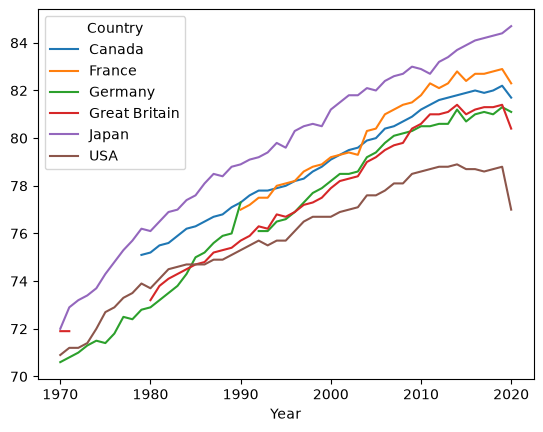

In [390]:
healthexp4.plot()
plt.show()

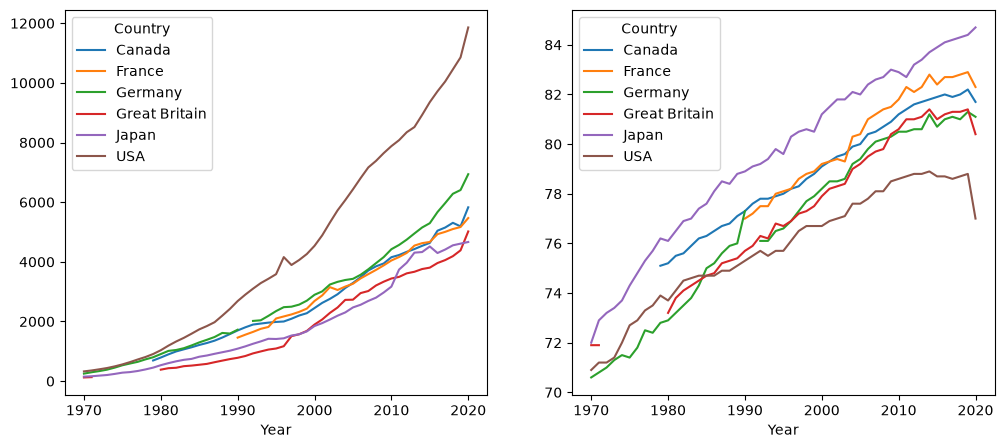

In [394]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
healthexp3.plot(ax=ax[0])
healthexp4.plot(ax=ax[1])
plt.show()

### Aggregation with wide form data

Note the wide form representations of a single measure in the space of two nominal identifiers allows for quick aggregation.

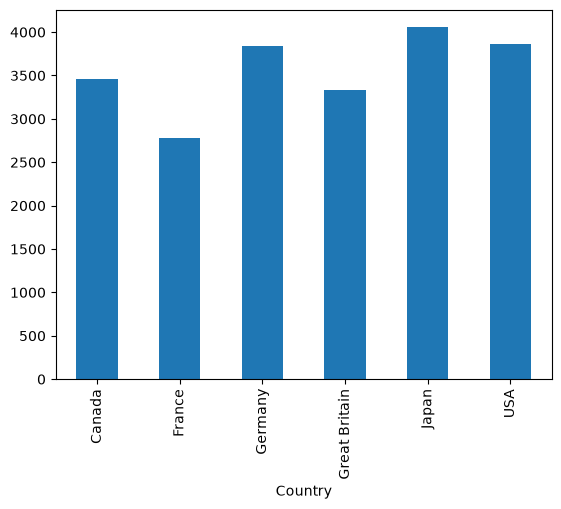

In [400]:
healthexp4.sum().plot.bar()
plt.show()

In [398]:
healthexp4.sum(axis=1)

Year
1970    357.6
1971    359.6
1972    215.4
1973    216.1
1974    217.2
1975    291.4
1976    293.3
1977    221.1
1978    221.6
1979    298.0
1980    445.4
1981    373.1
1982    374.6
1983    375.6
1984    377.1
1985    453.7
1986    379.3
1987    380.9
1988    381.3
1989    382.4
1990    461.5
1991    385.3
1992    462.6
1993    462.5
1994    464.7
1995    464.7
1996    466.6
1997    468.4
1998    469.7
1999    470.3
2000    472.3
2001    473.7
2002    474.5
2003    474.8
2004    478.1
2005    478.6
2006    480.9
2007    482.2
2008    482.9
2009    484.6
2010    485.6
2011    486.6
2012    487.3
2013    487.9
2014    489.8
2015    488.6
2016    489.7
2017    489.8
2018    490.1
2019    491.0
2020    487.2
dtype: float64

## Tips

### Long form (tidy)

Data are already aggregated by `sex`, `smoker`, `day`, and `time`. 

In [401]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Long form with key index

Identifying data are separated from measurement.

In [404]:
tips1 = tips.set_index(['sex','smoker','day','time'])
tips1

total_bill   tip  size
sex    smoker day  time                          
Female No     Sun  Dinner       16.99  1.01     2
Male   No     Sun  Dinner       10.34  1.66     3
                   Dinner       21.01  3.50     3
                   Dinner       23.68  3.31     2
Female No     Sun  Dinner       24.59  3.61     4
...                               ...   ...   ...
Male   No     Sat  Dinner       29.03  5.92     3
Female Yes    Sat  Dinner       27.18  2.00     2
Male   Yes    Sat  Dinner       22.67  2.00     2
       No     Sat  Dinner       17.82  1.75     2
Female No     Thur Dinner       18.78  3.00     2

[244 rows x 3 columns]

### Long form aggregation of two categories

In [433]:
tips2 = tips.groupby(['sex','day']).total_bill.agg(['mean','sum','min','max'])
tips2

mean      sum   min    max
sex    day                                  
Male   Thur  18.714667   561.44  7.51  41.19
       Fri   19.857000   198.57  8.58  40.17
       Sat   20.802542  1227.35  7.74  50.81
       Sun   21.887241  1269.46  7.25  48.17
Female Thur  16.715312   534.89  8.35  43.11
       Fri   14.145556   127.31  5.75  22.75
       Sat   19.680357   551.05  3.07  44.30
       Sun   19.872222   357.70  9.60  35.26

### Long form aggregation of three categories

In [432]:
tips3 = tips.groupby(['sex','day','smoker']).total_bill.agg(['mean','sum','min','max'])
tips3

mean     sum    min    max
sex    day  smoker                                 
Male   Thur Yes     19.171000  191.71  10.34  32.68
            No      18.486500  369.73   7.51  41.19
       Fri  Yes     20.452500  163.62   8.58  40.17
            No      17.475000   34.95  12.46  22.49
       Sat  Yes     21.837778  589.62   7.74  50.81
            No      19.929063  637.73   9.55  48.33
       Sun  Yes     26.141333  392.12   7.25  45.35
            No      20.403256  877.34   8.77  48.17
Female Thur Yes     19.218571  134.53  12.74  43.11
            No      16.014400  400.36   8.35  34.83
       Fri  Yes     12.654286   88.58   5.75  16.32
            No      19.365000   38.73  15.98  22.75
       Sat  Yes     20.266667  304.00   3.07  44.30
            No      19.003846  247.05   7.25  35.83
       Sun  Yes     16.540000   66.16   9.60  20.90
            No      20.824286  291.54  10.29  35.26

### Wide form aggregation by two categories

In [425]:
tips2['sum'].unstack()

day,Thur,Fri,Sat,Sun
sex,,,,
Male,561.44,198.57,1227.35,1269.46
Female,534.89,127.31,551.05,357.70


In [434]:
tips2['mean'].unstack()

day,Thur,Fri,Sat,Sun
sex,,,,
Male,18.714667,19.857000,20.802542,21.887241
Female,16.715312,14.145556,19.680357,19.872222


### Wide form aggregation by three categories

In [437]:
tips3['sum'].unstack()

smoker          Yes      No
sex    day                 
Male   Thur  191.71  369.73
       Fri   163.62   34.95
       Sat   589.62  637.73
       Sun   392.12  877.34
Female Thur  134.53  400.36
       Fri    88.58   38.73
       Sat   304.00  247.05
       Sun    66.16  291.54

In [440]:
tips3['mean'].unstack()

smoker             Yes         No
sex    day                       
Male   Thur  19.171000  18.486500
       Fri   20.452500  17.475000
       Sat   21.837778  19.929063
       Sun   26.141333  20.403256
Female Thur  19.218571  16.014400
       Fri   12.654286  19.365000
       Sat   20.266667  19.003846
       Sun   16.540000  20.824286

## Iris

### Long form (tidy)

Every row is an actual observation, i.e. it represents a unique plant.

In [441]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [450]:
iris.iloc[:, :-1].mean()

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

### Wide form, aggregated

In [443]:
iris1 = iris.groupby('species').agg(['mean','min','max'])
iris1

sepal_length           sepal_width           petal_length       \
                   mean  min  max        mean  min  max         mean  min   
species                                                                     
setosa            5.006  4.3  5.8       3.428  2.3  4.4        1.462  1.0   
versicolor        5.936  4.9  7.0       2.770  2.0  3.4        4.260  3.0   
virginica         6.588  4.9  7.9       2.974  2.2  3.8        5.552  4.5   

                petal_width            
            max        mean  min  max  
species                                
setosa      1.9       0.246  0.1  0.6  
versicolor  5.1       1.326  1.0  1.8  
virginica   6.9       2.026  1.4  2.5

In [447]:
iris2 = iris1.swaplevel(axis=1)['mean']
iris2

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [448]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


:::{note}
Although all three of the above tables are wide, the second two differ from the first in that all of their data come from the same variable domain.
:::

## Titannic

### Long form (tidy)

In [970]:
titanic = sns.load_dataset('titanic')
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [478]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Long form, augmented

In [475]:
titanic.loc[(titanic.who.isin(['man','woman'])), 'age_group'] = 'adult'
titanic.loc[titanic.who.isin(['child']), 'age_group'] = 'child'
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,adult


### Long form, subselected with key index

In [476]:
key_cols = ['sex', 'class', 'age_group']
titanic1 = titanic.set_index(key_cols)[['survived']]
titanic1

survived
sex    class  age_group          
male   Third  adult             0
female First  adult             1
       Third  adult             1
       First  adult             1
male   Third  adult             0
...                           ...
       Second adult             0
female First  adult             1
       Third  adult             0
male   First  adult             1
       Third  adult             0

[891 rows x 1 columns]

### Wide form, aggregated, with key index

In [486]:
titanic2 = titanic1.value_counts(key_cols + ['survived']).unstack().rename(columns={0:'no',1:'yes'})
titanic2.columns.name = 'survived'
titanic2

survived                  no  yes
sex    class  age_group          
male   First  adult       77   42
              child        0    3
       Second adult       91    8
              child        0    9
       Third  adult      281   38
              child       19    9
female First  adult        2   89
              child        1    2
       Second adult        6   60
              child        0   10
       Third  adult       58   56
              child       14   16

### Long form, aggregated, with key index, augmented

In [522]:
titanic3 = titanic2.yes.div(titanic2.sum(axis=1), axis=0).to_frame('survival_rate')
titanic3

survival_rate
sex    class  age_group               
male   First  adult           0.351901
              child           0.800000
       Second adult           0.080742
              child           0.909091
       Third  adult           0.119078
              child           0.317822
female First  adult           0.967732
              child           0.564103
       Second adult           0.896905
              child           0.916667
       Third  adult           0.489129
              child           0.524177

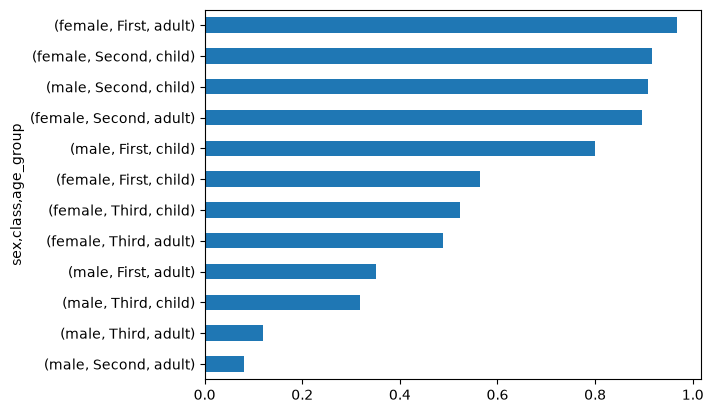

In [496]:
titanic3.sort_values().plot.barh()
plt.show()

### Wide form, aggregated

But remember the probabalities are conditional on the population that includes children.

In [513]:
titanic4 = titanic3.unstack()['adult'].unstack()
titanic4

class,First,Second,Third
sex,,,
male,0.351901,0.080742,0.119078
female,0.967732,0.896905,0.489129


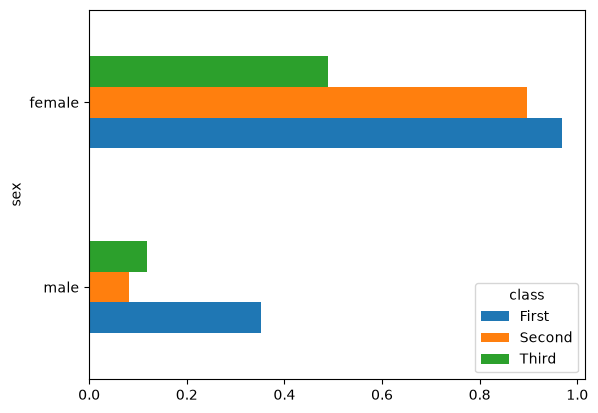

In [516]:
titanic4.plot.barh()
plt.show()

### Wide form, aggregated

These are wide forms generated by the simple count aggregation of survival rate by single categories.

In [528]:
titanic1.value_counts(['class','survived']).unstack()

survived,0,1
class,,
First,80,136
Second,97,87
Third,372,119


In [529]:
titanic1.value_counts(['sex','survived']).unstack()

survived,0,1
sex,,
male,468,109
female,81,233


In [530]:
titanic1.value_counts(['age_group','survived']).unstack()

survived,0,1
age_group,,
adult,515,293
child,34,49


## Anscombe

### Long form, combined

The data set used to produce Anscombe's Quartet, a powerful visualization that demonstrates the value of vizualization itself.

In [571]:
anscombe = sns.load_dataset('anscombe')
anscombe

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


The issuse here is that there are four independent datasets with the same shape combined into one data frame.

By design, they come from completely different populations and distributions.

So, from a datalogical perspective, they shouldn't be combined in a single data frame.

A good idea is to put them into a dictionary.

### Long form, separated

In [687]:
anscombe_dict = {}
for ds_name, ds in anscombe.groupby('dataset'):
    anscombe_dict[ds_name] = ds[['x','y']].reset_index(drop=True)

In [688]:
anscombe_dict['II']

,x,y
0,10.0,9.14
1,8.0,8.14
2,13.0,8.74
3,9.0,8.77
4,11.0,9.26
5,14.0,8.10
6,6.0,6.13
7,4.0,3.10
8,12.0,9.13
9,7.0,7.26


Then, to show the individual scatter plots, we iterate through the dict.

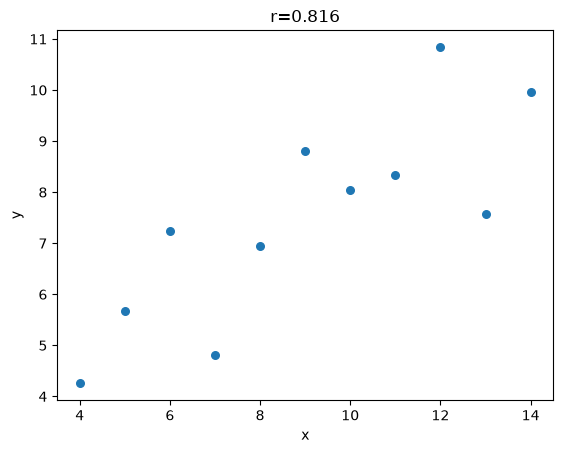

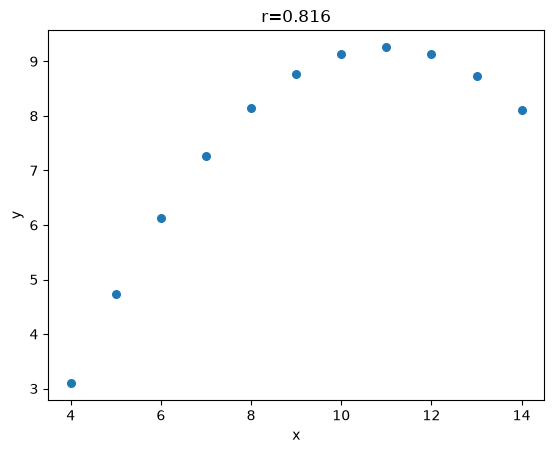

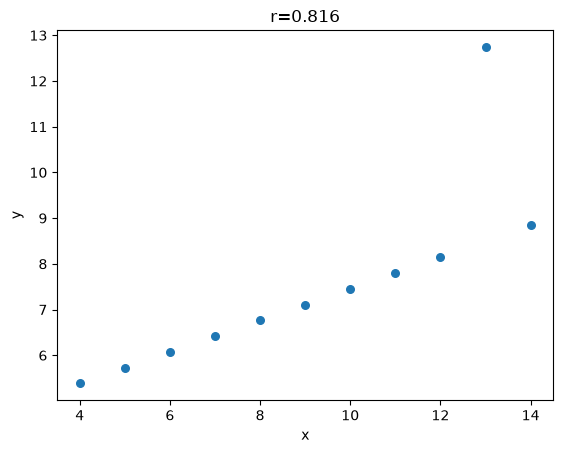

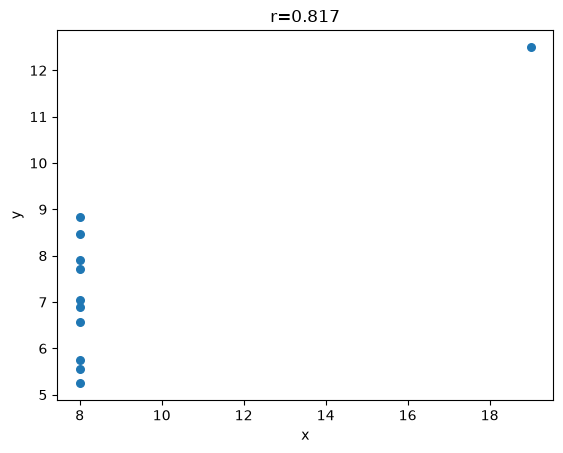

In [676]:
for ds_name, ds in anscombe_dict.items():
    ds.corr()
    ds.plot.scatter(x='x', y='y', s=30, title="r="+str(ds.corr().iloc[0,1].round(3)))

Now, if we _really_ wanted to, we can combine the data frames into one.

A good way to do this is with Pandas' `pd.concat()` function.

Here we convert the dict into a data frame.

### Long form, combined with key column index

In [693]:
ANSCOMBE = pd.concat([df for df in anscombe_dict.values()], keys=list(anscombe_dict.keys()), axis=1)
ANSCOMBE

I           II         III           IV       
       x      y     x     y     x      y     x      y
0   10.0   8.04  10.0  9.14  10.0   7.46   8.0   6.58
1    8.0   6.95   8.0  8.14   8.0   6.77   8.0   5.76
2   13.0   7.58  13.0  8.74  13.0  12.74   8.0   7.71
3    9.0   8.81   9.0  8.77   9.0   7.11   8.0   8.84
4   11.0   8.33  11.0  9.26  11.0   7.81   8.0   8.47
5   14.0   9.96  14.0  8.10  14.0   8.84   8.0   7.04
6    6.0   7.24   6.0  6.13   6.0   6.08   8.0   5.25
7    4.0   4.26   4.0  3.10   4.0   5.39  19.0  12.50
8   12.0  10.84  12.0  9.13  12.0   8.15   8.0   5.56
9    7.0   4.82   7.0  7.26   7.0   6.42   8.0   7.91
10   5.0   5.68   5.0  4.74   5.0   5.73   8.0   6.89

In [678]:
ANSCOMBE.II

,x,y
0,10.0,9.14
1,8.0,8.14
2,13.0,8.74
3,9.0,8.77
4,11.0,9.26
5,14.0,8.10
6,6.0,6.13
7,4.0,3.10
8,12.0,9.13
9,7.0,7.26


Again, we iterate through the container (this time a data frame) to produce the individual plots.

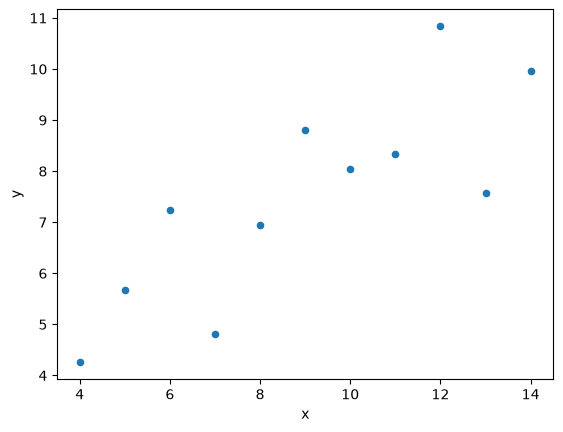

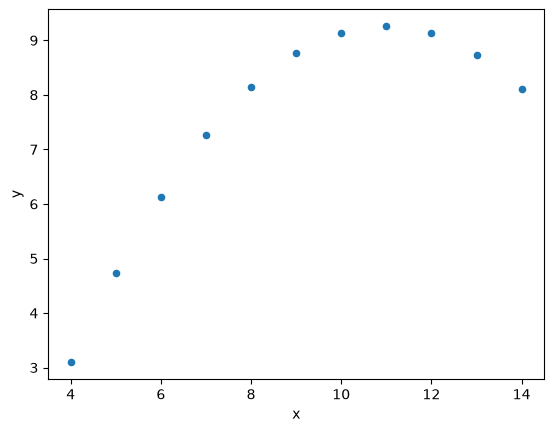

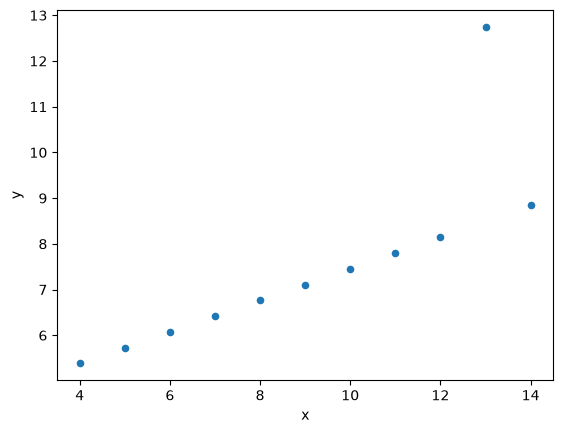

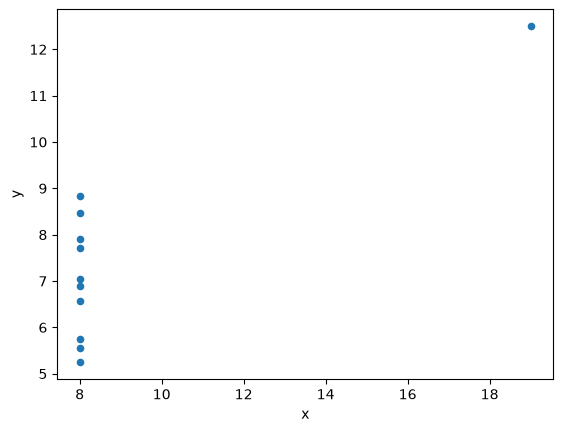

In [686]:
for i, ds_name in enumerate(ANSCOMBE.columns.unique(0).tolist()): 
    ANSCOMBE[ds_name].plot.scatter(x='x', y='y')
plt.show() 

## Attention

### Long form (tidy)

In [971]:
attention = sns.load_dataset('attention')
attention.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  60 non-null     int64  
 1   subject     60 non-null     int64  
 2   attention   60 non-null     str    
 3   solutions   60 non-null     int64  
 4   score       60 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 2.5 KB


In [972]:
attention.head()

,Unnamed: 0,subject,attention,solutions,score
0,0,1,divided,1,2.0
1,1,2,divided,1,3.0
2,2,3,divided,1,3.0
3,3,4,divided,1,5.0
4,4,5,divided,1,4.0


### Long form with key index

In [705]:
attention_key = ['subject', 'attention', 'solutions']
attention_measure = ['score']
attention1 = attention.set_index(attention_key)[attention_measure]
attention1.head()

,,,score
subject,attention,solutions,
1,divided,1,2.0
2,divided,1,3.0
3,divided,1,3.0
4,divided,1,5.0
5,divided,1,4.0


### Wide form aggregated

In [707]:
attention2 = attention1.groupby(['attention','solutions']).score.mean().unstack()
attention2

solutions,1,2,3
attention,,,
divided,4.0,4.95,6.4
focused,6.7,7.00,6.7


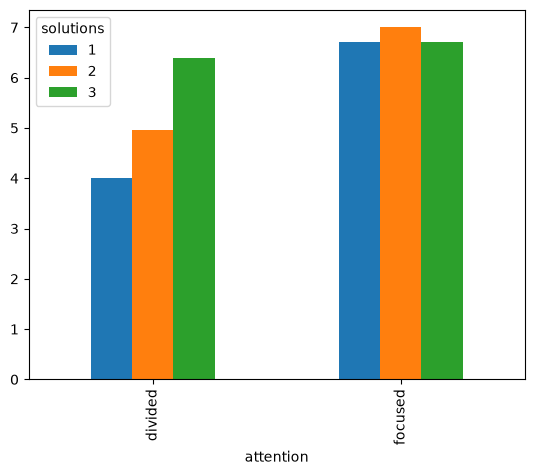

In [709]:
attention2.plot.bar()
plt.show()

## Penguins

In [976]:
penguins = sns.load_dataset('penguins')
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


### Long form (tidy)

In [975]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


### Long form with key index

In [711]:
penguins_key = ['species', 'island', 'sex']
penguins1 = penguins.set_index(penguins_key)
penguins1

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species island    sex                                                        
Adelie  Torgersen Male              39.1           18.7              181.0   
                  Female            39.5           17.4              186.0   
                  Female            40.3           18.0              195.0   
                  nan                NaN            NaN                NaN   
                  Female            36.7           19.3              193.0   
...                                  ...            ...                ...   
Gentoo  Biscoe    nan                NaN            NaN                NaN   
                  Female            46.8           14.3              215.0   
                  Male              50.4           15.7              222.0   
                  Female            45.2           14.8              212.0   
                  Male              49.9           16.1              213.0   

                          body_mass_g  
species island    sex                  
Adelie  Torgersen Male         3750.0  
                  Female       3800.0  
                  Female       3250.0  
                  nan             NaN  
                  Female       3450.0  
...                               ...  
Gentoo  Biscoe    nan             NaN  
                  Female       4850.0  
                  Male         5750.0  
                  Female       5200.0  
                  Male         5400.0  

[344 rows x 4 columns]

### Long form aggregated by two nominal identifiers

In [729]:
penguins2a = penguins1.groupby(['species','island']).mean()
penguins2a

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   island                                                        
Adelie    Biscoe          38.975000      18.370455         188.795455   
          Dream           38.501786      18.251786         189.732143   
          Torgersen       38.950980      18.429412         191.196078   
Chinstrap Dream           48.833824      18.420588         195.823529   
Gentoo    Biscoe          47.504878      14.982114         217.186992   

                     body_mass_g  
species   island                  
Adelie    Biscoe     3709.659091  
          Dream      3688.392857  
          Torgersen  3706.372549  
Chinstrap Dream      3733.088235  
Gentoo    Biscoe     5076.016260

In [716]:
penguins2b = penguins1.groupby(['species','sex']).mean()
penguins2b

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    Female       37.257534      17.621918         187.794521   
          Male         40.390411      19.072603         192.410959   
Chinstrap Female       46.573529      17.588235         191.735294   
          Male         51.094118      19.252941         199.911765   
Gentoo    Female       45.563793      14.237931         212.706897   
          Male         49.473770      15.718033         221.540984   

                  body_mass_g  
species   sex                  
Adelie    Female  3368.835616  
          Male    4043.493151  
Chinstrap Female  3527.205882  
          Male    3938.970588  
Gentoo    Female  4679.741379  
          Male    5484.836066

In [717]:
penguins2c = penguins1.groupby(['island','sex']).mean()
penguins2c

bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    sex                                                        
Biscoe    Female       43.307500      15.191250         205.687500   
          Male         47.119277      16.597590         213.289157   
Dream     Female       42.296721      17.601639         190.016393   
          Male         46.116129      19.066129         196.306452   
Torgersen Female       37.554167      17.550000         188.291667   
          Male         40.586957      19.391304         194.913043   

                  body_mass_g  
island    sex                  
Biscoe    Female  4319.375000  
          Male    5104.518072  
Dream     Female  3446.311475  
          Male    3987.096774  
Torgersen Female  3395.833333  
          Male    4034.782609

### Wide form aggregated by two nominal identifiers on one measure

In [726]:
penguins2a.bill_length_mm.unstack()

island,Biscoe,Dream,Torgersen
species,,,
Adelie,38.975000,38.501786,38.95098
Chinstrap,NaN,48.833824,NaN
Gentoo,47.504878,NaN,NaN


In [727]:
penguins2c.body_mass_g.unstack()

sex,Female,Male
island,,
Biscoe,4319.375000,5104.518072
Dream,3446.311475,3987.096774
Torgersen,3395.833333,4034.782609


## Car crashes

This dataset provides a state-by-state breakdown of fatal motor vehicle collisions in the United States. 

It includes $8$ variables (features) to analyze factors contributing to fatal accidents.


- `total`: Fatal collisions per billion miles. To calculate this number, statisticians take the total number of fatal crashes in a state and divide it by the total Vehicle Miles Traveled (VMT) by all drivers in that state over a year. Because total miles driven across an entire state is an incredibly massive number, the result is multiplied by one billion to make the final figure easy to read and compare (e.g., "15.2" crashes instead of "0.0000000152").
- `speeding`, `alcohol`, `not_distracted`, `no_previous`: Percentages representing factors in fatal collisions.
- `ins_premium`, `ins_losses`: Currency $\$$ values representing insurance costs.



### Long form 

In [981]:
crashes = sns.load_dataset('car_crashes')
crashes.info()
crashes.head()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     str    
dtypes: float64(7), str(1)
memory usage: 3.3 KB


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


### Long form with key index

In [738]:
crashes1 = crashes.set_index('abbrev')
crashes1.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
abbrev,,,,,,,
AL,18.8,7.332,5.640,18.048,15.040,784.55,145.08
AK,18.1,7.421,4.525,16.290,17.014,1053.48,133.93
AZ,18.6,6.510,5.208,15.624,17.856,899.47,110.35
AR,22.4,4.032,5.824,21.056,21.280,827.34,142.39
CA,12.0,4.200,3.360,10.920,10.680,878.41,165.63


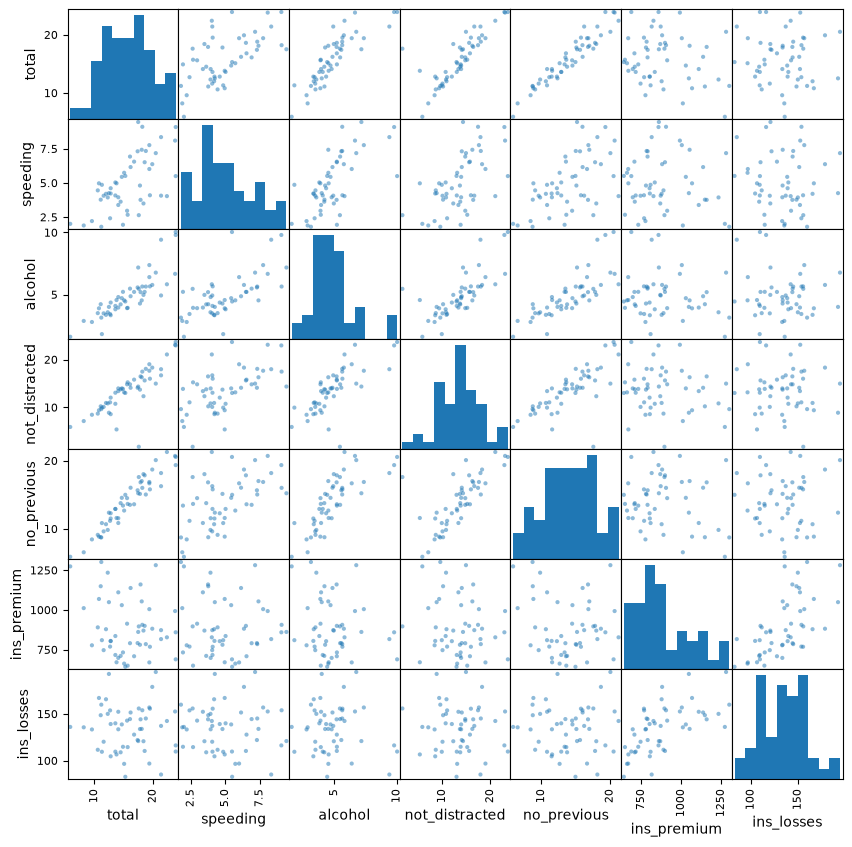

In [743]:
pd.plotting.scatter_matrix(crashes1, figsize=(10,10))
plt.show()

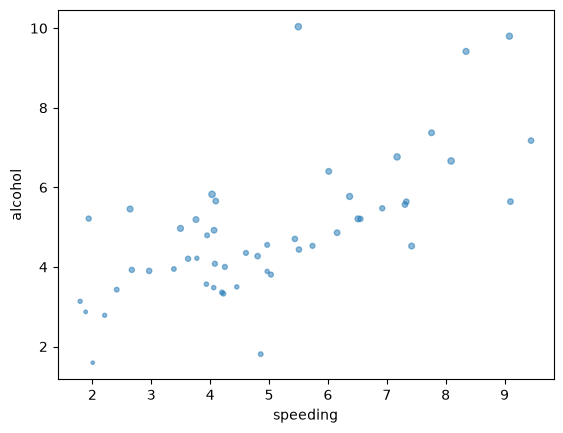

In [750]:
crashes1.plot.scatter(x='speeding', y='alcohol', s='no_previous', alpha=.5)
plt.show()

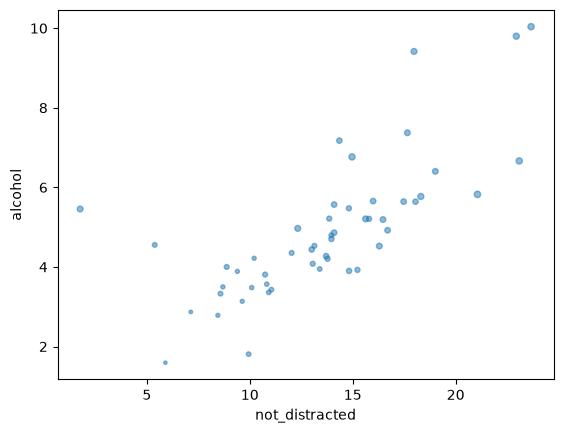

In [762]:
crashes1.plot.scatter(x='not_distracted', y='alcohol', s='no_previous', alpha=.5)
plt.show()

## Diamonds

This dataset contains information on $53,940$ individual diamonds. 

Uses for exploring multi-variable relationships, training regression models, and practicing data cleaning.

**Data Dictionary**
The dataset consists of 10 columns capturing the physical measurements, gemological rankings (the "Four Cs"), and pricing information for each diamond. [3, 6] 

:::{table}
| Variable | Data Type | Domain / Range | Description |
|---|---|---|---|
| price | Integer | $326 – $18,823 | The retail price of the diamond in US dollars. |
| carat | Continuous | 0.2 – 5.01 | The physical weight of the diamond. |
| cut | Categorical (Ordinal) | Fair, Good, Very Good, Premium, Ideal | Quality rating of the diamond's cut, ranging from lowest quality (Fair) to highest (Ideal). |
| color | Categorical (Ordinal) | J (worst) to D (best) | Diamond color rating. "D" represents a completely colorless/premium diamond, while "J" represents a noticeable yellow tint. |
| clarity | Categorical (Ordinal) | I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best) | Measurement of internal flaws or surface blemishes. I1 stands for Included, while IF stands for Internally Flawless. |
| x | Continuous | 0 – 10.74 mm | Length of the diamond in millimeters. |
| y | Continuous | 0 – 58.9 mm | Width of the diamond in millimeters. |
| z | Continuous | 0 – 31.8 mm | Depth of the diamond in millimeters. |
| depth | Continuous | 43% – 79% | Total depth percentage. Calculated mathematically as: $\frac{2 \times z}{x + y}$. |
| table | Continuous | 43% – 95% | The width of the diamond's top facet (the "table") relative to its widest point. |
:::

### Long form (tidy)

No key to create an index.

In [980]:
diamonds = sns.load_dataset('diamonds')
diamonds.info()
diamonds

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [800]:
diamonds['vol'] = diamonds.x * diamonds.y * diamonds.z
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z,vol
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,115.920000
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,118.110175
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,114.449728
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,140.766120


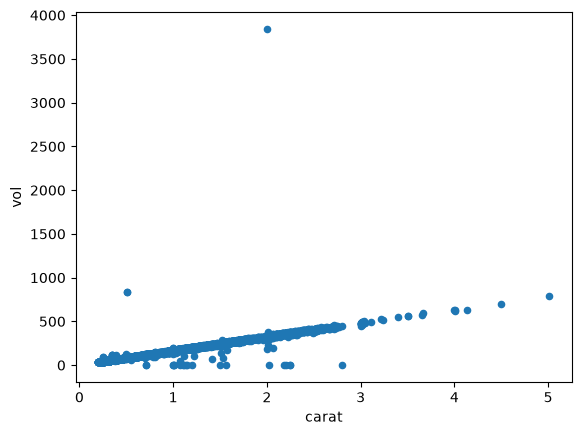

In [803]:
diamonds.plot.scatter('carat','vol')
plt.show()

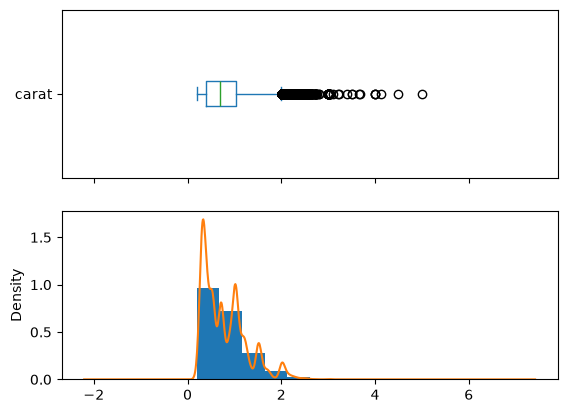

In [817]:
fig, ax = plt.subplots(2, 1, sharex=True)
diamonds.carat.plot.box(vert=False, ax=ax[0])
diamonds.carat.plot.hist(ax=ax[1], density=True)
diamonds.carat.plot.kde(ax=ax[1])
plt.show()

In [820]:
diamonds1a = diamonds.value_counts(['cut', 'clarity']).unstack()
diamonds1a

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
cut,,,,,,,,
Ideal,1212,2047,2606,3589,5071,4282,2598,146
Premium,230,616,870,1989,3357,3575,2949,205
Very Good,268,789,1235,1775,2591,3240,2100,84
Good,71,186,286,648,978,1560,1081,96
Fair,9,17,69,170,261,408,466,210


In [821]:
diamonds1a.style.background_gradient(axis=None)

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
cut,,,,,,,,
Ideal,1212,2047,2606,3589,5071,4282,2598,146
Premium,230,616,870,1989,3357,3575,2949,205
Very Good,268,789,1235,1775,2591,3240,2100,84
Good,71,186,286,648,978,1560,1081,96
Fair,9,17,69,170,261,408,466,210


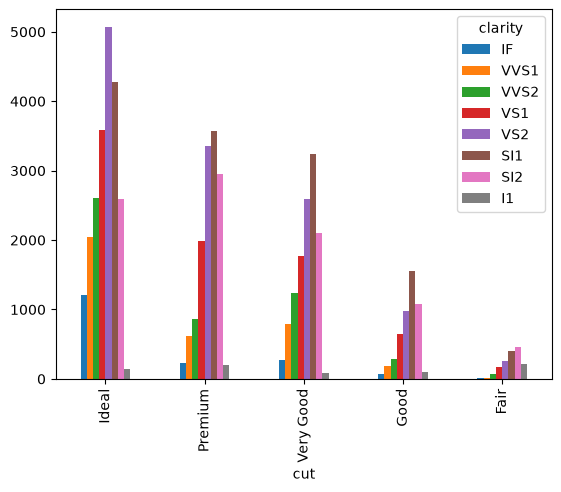

In [822]:
diamonds1a.plot.bar(stacked=False)
plt.show()

In [823]:
diamonds1b = diamonds.value_counts(['cut', 'color']).unstack()
diamonds1b

color,D,E,F,G,H,I,J
cut,,,,,,,
Ideal,2834,3903,3826,4884,3115,2093,896
Premium,1603,2337,2331,2924,2360,1428,808
Very Good,1513,2400,2164,2299,1824,1204,678
Good,662,933,909,871,702,522,307
Fair,163,224,312,314,303,175,119


In [830]:
diamonds1b.style.background_gradient(axis=None)

color,D,E,F,G,H,I,J
cut,,,,,,,
Ideal,2834,3903,3826,4884,3115,2093,896
Premium,1603,2337,2331,2924,2360,1428,808
Very Good,1513,2400,2164,2299,1824,1204,678
Good,662,933,909,871,702,522,307
Fair,163,224,312,314,303,175,119


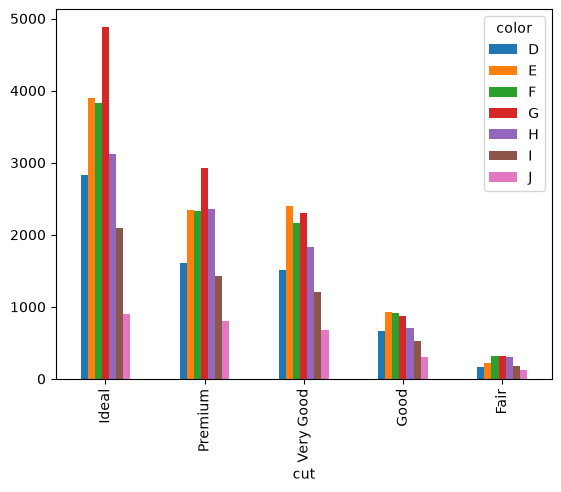

In [825]:
diamonds1b.plot.bar(stacked=False)
plt.show()

In [824]:
diamonds1c = diamonds.value_counts(['color', 'clarity']).unstack()
diamonds1c

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
color,,,,,,,,
D,73,252,553,705,1697,2083,1370,42
E,158,656,991,1281,2470,2426,1713,102
F,385,734,975,1364,2201,2131,1609,143
G,681,999,1443,2148,2347,1976,1548,150
H,299,585,608,1169,1643,2275,1563,162
I,143,355,365,962,1169,1424,912,92
J,51,74,131,542,731,750,479,50


In [831]:
diamonds1c.style.background_gradient(axis=None)

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
color,,,,,,,,
D,73,252,553,705,1697,2083,1370,42
E,158,656,991,1281,2470,2426,1713,102
F,385,734,975,1364,2201,2131,1609,143
G,681,999,1443,2148,2347,1976,1548,150
H,299,585,608,1169,1643,2275,1563,162
I,143,355,365,962,1169,1424,912,92
J,51,74,131,542,731,750,479,50


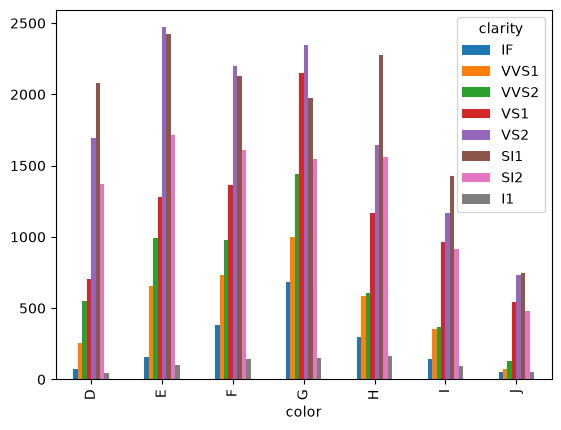

In [828]:
diamonds1c.plot.bar(stacked=False)
plt.show()

## MPG

### Long form (tidy)

In [869]:
mpg = sns.load_dataset('mpg')
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


### Long form with key index

In [870]:
mpg1 = mpg.set_index(['name'])
mpg1

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86.0,2790,15.6,82,usa
vw pickup,44.0,4,97.0,52.0,2130,24.6,82,europe
dodge rampage,32.0,4,135.0,84.0,2295,11.6,82,usa


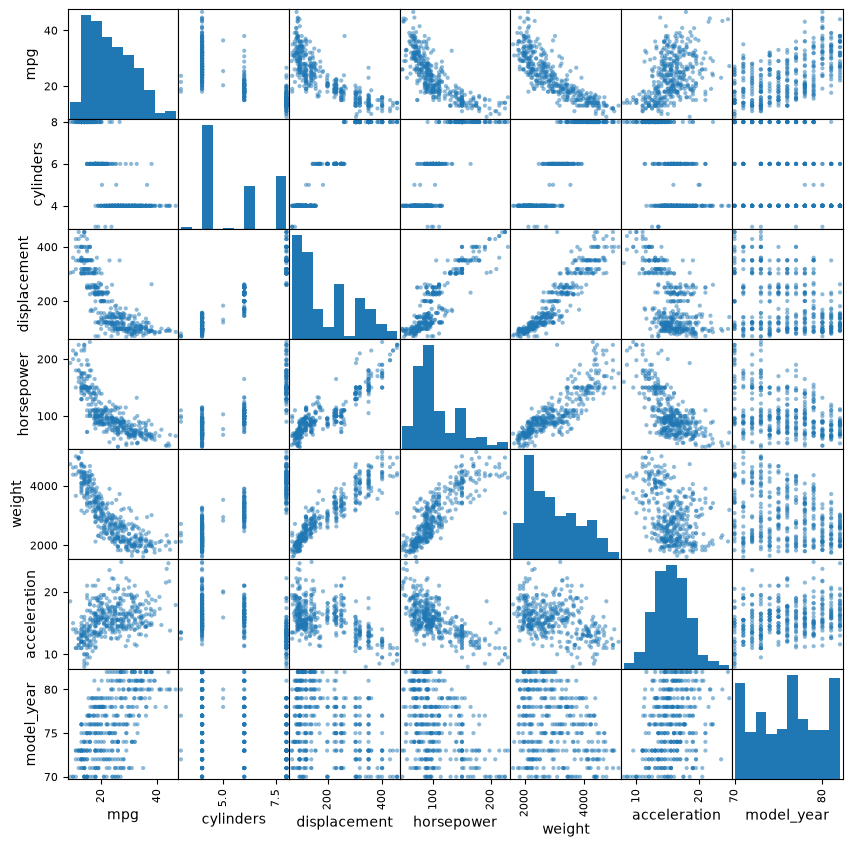

In [879]:
pd.plotting.scatter_matrix(mpg1, figsize=(10,10))
plt.show()

### Long form aggregate of all measures by joint nominals with multiple aggfuncs

In [880]:
mpg_nominals = ['model_year', 'origin']
mpg_measures = list(mpg1.columns)[:-2]
mpg2 = mpg1.groupby(mpg_nominals)[mpg_measures].agg(['mean','min','max'])
mpg2

mpg             cylinders         displacement  \
                        mean   min   max      mean min max         mean   
model_year origin                                                         
70         europe  25.200000  24.0  26.0  4.000000   4   4   107.800000   
           japan   25.500000  24.0  27.0  4.000000   4   4   105.000000   
           usa     15.272727   9.0  22.0  7.636364   6   8   336.909091   
71         europe  28.750000  27.0  30.0  4.000000   4   4    95.000000   
           japan   29.500000  25.0  35.0  4.000000   4   4    88.250000   
           usa     18.100000  12.0  28.0  6.200000   4   8   257.000000   
72         europe  22.000000  18.0  26.0  4.000000   4   4   111.000000   
           japan   24.200000  19.0  28.0  3.800000   3   4    99.400000   
           usa     16.277778  11.0  28.0  6.888889   4   8   281.250000   
73         europe  24.000000  19.0  29.0  4.000000   4   4   105.000000   
           japan   20.000000  18.0  22.0  4.250000   3   6   107.750000   
           usa     15.034483  11.0  23.0  7.241379   4   8   314.103448   
74         europe  27.000000  24.0  31.0  4.000000   4   4    93.166667   
           japan   29.333333  24.0  32.0  4.000000   4   4    89.500000   
           usa     18.333333  13.0  28.0  6.266667   4   8   236.066667   
75         europe  24.500000  22.0  29.0  4.000000   4   4   109.500000   
           japan   27.500000  24.0  33.0  4.000000   4   4   110.250000   
           usa     17.550000  13.0  23.0  6.400000   4   8   253.400000   
76         europe  24.250000  16.5  29.5  4.250000   4   6   116.125000   
           japan   28.000000  19.0  33.0  4.500000   4   6   107.250000   
           usa     19.431818  13.0  29.0  6.363636   4   8   243.954545   
77         europe  29.250000  21.5  36.0  4.000000   4   4    98.500000   
           japan   27.416667  21.5  33.5  4.166667   3   6   100.500000   
           usa     20.722222  15.0  33.5  6.222222   4   8   242.333333   
78         europe  24.950000  16.2  43.1  4.833333   4   6   126.166667   
           japan   29.687500  21.1  39.4  4.000000   4   4   107.250000   
           usa     21.772727  17.5  36.1  6.000000   4   8   217.545455   
79         europe  30.450000  25.4  37.3  4.250000   4   5   126.000000   
           japan   32.950000  31.8  34.1  4.000000   4   4    85.500000   
           usa     23.478261  15.5  35.7  6.260870   4   8   231.260870   
80         europe  37.288889  29.8  44.3  4.111111   4   5   104.222222   
           japan   35.400000  23.7  46.6  4.076923   3   6   104.615385   
           usa     25.914286  19.1  32.1  4.285714   4   6   151.571429   
81         europe  31.575000  28.1  34.5  4.500000   4   6   122.750000   
           japan   32.958333  24.2  39.1  4.333333   4   6   107.500000   
           usa     27.530769  17.6  39.0  4.923077   4   8   164.846154   
82         europe  40.000000  36.0  44.0  4.000000   4   4   101.000000   
           japan   34.888889  31.0  38.0  4.000000   4   4   103.777778   
           usa     29.450000  22.0  38.0  4.300000   4   6   142.950000   

                                 horsepower                    weight        \
                     min    max        mean   min    max         mean   min   
model_year origin                                                             
70         europe   97.0  121.0   86.200000  46.0  113.0  2309.200000  1835   
           japan    97.0  113.0   91.500000  88.0   95.0  2251.000000  2130   
           usa     198.0  455.0  166.954545  85.0  225.0  3716.500000  2587   
71         europe   79.0  116.0   74.000000  60.0   90.0  2024.000000  1834   
           japan    71.0  113.0   79.250000  65.0   95.0  1936.000000  1613   
           usa      91.0  400.0  119.842105  70.0  180.0  3401.600000  1955   
72         europe   96.0  121.0   79.600000  54.0  112.0  2573.200000  2189   
           japan    70.0  120.0   93.800000  88.0   97.0  2300.400000  2100   
     

### Wide form, aggregate one measure by two nominals

With `mpg2`, we can access wide table respresenations of any aggregregated feature by simple column selection and unstacking.

In [898]:
mpg_feature = 'mpg'
mpg_aggfunc = 'mean'
mpg3a = mpg2[(mpg_feature, mpg_aggfunc)].unstack()
mpg3a

origin,europe,japan,usa
model_year,,,
70,25.200000,25.500000,15.272727
71,28.750000,29.500000,18.100000
72,22.000000,24.200000,16.277778
73,24.000000,20.000000,15.034483
74,27.000000,29.333333,18.333333
75,24.500000,27.500000,17.550000
76,24.250000,28.000000,19.431818
77,29.250000,27.416667,20.722222
78,24.950000,29.687500,21.772727


In [899]:
mpg_feature = 'horsepower'
mpg_aggfunc = 'mean'
mpg3b = mpg2[(mpg_feature, mpg_aggfunc)].unstack()
mpg3b

origin,europe,japan,usa
model_year,,,
70,86.200000,91.500000,166.954545
71,74.000000,79.250000,119.842105
72,79.600000,93.800000,138.777778
73,81.857143,98.500000,146.620690
74,74.166667,72.500000,112.142857
75,89.500000,80.250000,108.700000
76,87.625000,76.500000,110.500000
77,81.000000,81.166667,118.388889
78,99.166667,79.250000,107.272727


Getting the same result from `mpg1`.

In [931]:
mpg1.groupby(['model_year', 'origin'])[mpg_feature].agg(mpg_aggfunc).unstack()

origin,europe,japan,usa
model_year,,,
70,86.200000,91.500000,166.954545
71,74.000000,79.250000,119.842105
72,79.600000,93.800000,138.777778
73,81.857143,98.500000,146.620690
74,74.166667,72.500000,112.142857
75,89.500000,80.250000,108.700000
76,87.625000,76.500000,110.500000
77,81.000000,81.166667,118.388889
78,99.166667,79.250000,107.272727


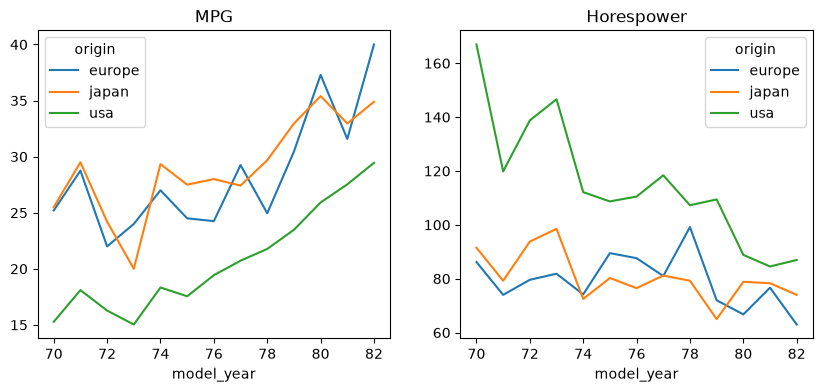

In [932]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
mpg3a.plot(ax=ax[0], title="MPG")
mpg3b.plot(ax=ax[1], title="Horespower")
plt.show()

### Wide form aggregate of all measures by one nominal

In [920]:
mpg4a = mpg1.groupby('model_year')[mpg_measures].mean()
mpg4a

,mpg,cylinders,displacement,horsepower,weight,acceleration
model_year,,,,,,
70,17.689655,6.758621,281.413793,147.827586,3372.793103,12.948276
71,21.250000,5.571429,209.750000,107.037037,2995.428571,15.142857
72,18.714286,5.821429,218.375000,120.178571,3237.714286,15.125000
73,17.100000,6.375000,256.875000,130.475000,3419.025000,14.312500
74,22.703704,5.259259,171.740741,94.230769,2877.925926,16.203704
75,20.266667,5.600000,205.533333,101.066667,3176.800000,16.050000
76,21.573529,5.647059,197.794118,101.117647,3078.735294,15.941176
77,23.375000,5.464286,191.392857,105.071429,2997.357143,15.435714
78,24.061111,5.361111,177.805556,99.694444,2861.805556,15.805556


In [921]:
mpg4b = mpg1.groupby('origin')[mpg_measures].mean()
mpg4b

,mpg,cylinders,displacement,horsepower,weight,acceleration
origin,,,,,,
europe,27.891429,4.157143,109.142857,80.558824,2423.300000,16.787143
japan,30.450633,4.101266,102.708861,79.835443,2221.227848,16.172152
usa,20.083534,6.248996,245.901606,119.048980,3361.931727,15.033735


### Wide form normed by z-score

Norming the data in a dataframe with multiple features allows us to compare trends.

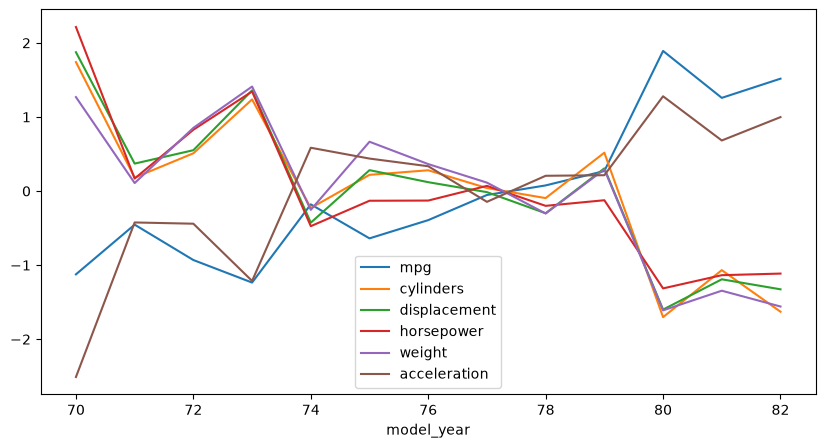

In [927]:
((mpg4a - mpg4a.mean()) / mpg4a.std()).plot(figsize=(10, 5))
plt.show()

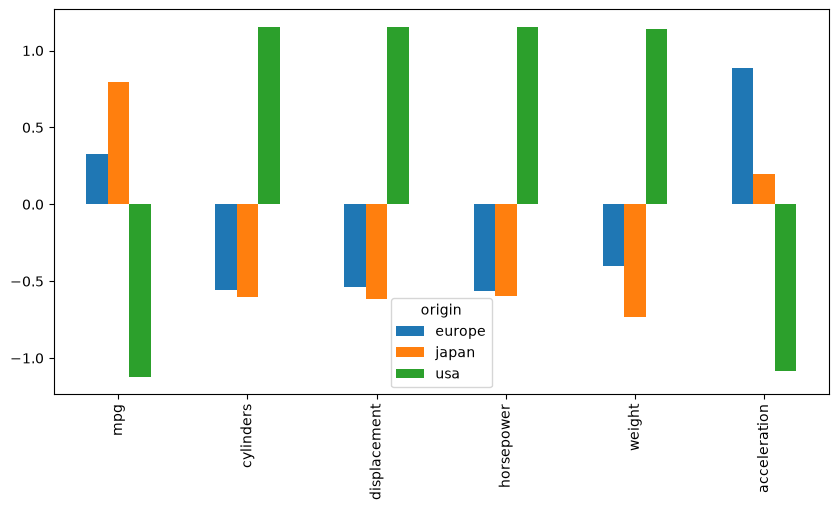

In [935]:
((mpg4b - mpg4b.mean()) / mpg4b.std()).T.plot.bar(figsize=(10, 5))
plt.show()

## Taxis

**Use cases**

- Network diagrams
- Alluvial diagrams
- Flow diagrams (a la Minard)

### Long form (tidy)

In [999]:
taxis = sns.load_dataset('taxis')
taxis.info()
taxis

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [1000]:
taxis_places1 = ['pickup_zone', 'dropoff_zone']
taxis_places2 = ['pickup_borough', 'dropoff_borough']
taxis_times = ['pickup', 'dropoff']
taxis_nominals = ['color', 'payment']
taxis_measures = ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']

In [1006]:
taxis.value_counts(taxis_places1).to_frame('n')

,,n
pickup_zone,dropoff_zone,
Upper East Side North,Upper East Side North,38
Upper East Side South,Upper East Side North,30
Astoria,Astoria,24
Upper East Side North,Upper East Side South,23
Central Harlem,Central Harlem North,20
...,...,...
Saint Albans,Hillcrest/Pomonok,1
Park Slope,East New York,1
Jamaica,East Concourse/Concourse Village,1


In [1018]:
taxis.groupby(taxis_places1).fare.mean().to_frame('mean_fare').sort_values('mean_fare', ascending=False) #.head(50).plot.bar(figsize=(10,5))

,,mean_fare
pickup_zone,dropoff_zone,
Sunset Park West,Saint Albans,93.50
Coney Island,Upper East Side North,86.14
University Heights/Morris Heights,Yorkville East,81.86
Parkchester,Flatbush/Ditmas Park,71.20
East Harlem North,Brooklyn Heights,70.00
...,...,...
Hudson Sq,Hudson Sq,2.50
Rosedale,Rosedale,2.50
Williamsbridge/Olinville,Williamsbridge/Olinville,2.50


In [988]:
taxis.value_counts(taxis_places2).unstack(fill_value=0)

dropoff_borough,Manhattan,Queens,Brooklyn,Bronx,Staten Island
pickup_borough,,,,,
Manhattan,4885,163,153,55,2
Queens,224,349,62,11,0
Bronx,25,4,4,66,0
Brooklyn,67,26,282,5,0


In [994]:
taxis.groupby(taxis_places1)[taxis_measures].mean().sort_values('total', ascending=False)

,,passengers,distance,fare,tip,tolls,total
pickup_zone,dropoff_zone,,,,,,
Sunset Park West,Saint Albans,1.0,25.51,93.50,0.000,0.00,94.800
Coney Island,Upper East Side North,1.0,20.64,86.14,0.000,5.76,92.400
University Heights/Morris Heights,Yorkville East,1.0,22.17,81.86,0.000,0.00,82.360
TriBeCa/Civic Center,West Brighton,1.0,15.51,44.00,16.270,17.28,81.350
JFK Airport,Cobble Hill,1.0,20.41,62.75,14.595,0.00,79.145
...,...,...,...,...,...,...,...
Cobble Hill,Cobble Hill,1.0,0.00,2.50,0.000,0.00,3.300
Rosedale,Rosedale,1.0,0.00,2.50,0.000,0.00,3.300
Hunts Point,Hunts Point,1.0,0.00,2.50,0.000,0.00,3.300


In [995]:
taxis.groupby(taxis_places2)[taxis_measures].mean().sort_values('total', ascending=False)

passengers   distance       fare        tip  \
pickup_borough dropoff_borough                                                
Manhattan      Staten Island      1.000000  15.855000  44.500000  14.165000   
Brooklyn       Bronx              1.400000  19.600000  58.124000   0.000000   
Bronx          Brooklyn           1.000000  13.492500  54.062500   0.000000   
Queens         Bronx              1.363636  16.636364  45.772727   1.577273   
               Manhattan          1.558036  11.968884  36.923839   6.194330   
Manhattan      Queens             1.668712  10.976748  34.623804   5.904663   
Bronx          Queens             1.000000  14.030000  40.157500   0.000000   
Queens         Brooklyn           1.709677  11.884194  37.018871   4.145806   
Brooklyn       Queens             1.346154  10.874615  34.842692   1.400769   
Manhattan      Brooklyn           1.477124   6.669608  24.495098   3.402026   
Bronx          Manhattan          1.040000   8.562800  29.698000   0.335600   
Brooklyn       Manhattan          1.507463   6.950597  25.096567   2.331493   
Manhattan      Bronx              1.290909   6.948727  24.127273   0.891818   
Bronx          Bronx              1.272727   3.677273  14.539091   0.095758   
Queens         Queens             1.467049   3.157765  12.812178   0.843782   
Manhattan      Manhattan          1.569089   1.855879   9.727019   1.761994   
Brooklyn       Brooklyn           1.262411   2.510780  11.877589   0.629362   

                                    tolls      total  
pickup_borough dropoff_borough                        
Manhattan      Staten Island    14.400000  76.865000  
Brooklyn       Bronx             5.760000  64.824000  
Bronx          Brooklyn          4.320000  59.032500  
Queens         Bronx             4.985455  53.417273  
               Manhattan         4.424286  51.056518  
Manhattan      Queens            3.413988  47.355337  
Bronx          Queens            5.760000  46.567500  
Queens         Brooklyn          0.000000  42.351774  
Brooklyn       Queens            0.000000  37.224231  
Manhattan      Brooklyn          0.676209  32.164183  
Bronx          Manhattan         1.132800  31.942400  
Brooklyn       Manhattan         1.203582  31.483881  
Manhattan      Bronx             0.248727  27.082364  
Bronx          Bronx             0.127273  15.648485  
Queens         Queens            0.134842  14.973610  
Manhattan      Manhattan         0.005277  14.945734  
Brooklyn       Brooklyn          0.000000  13.701454

## Planets

This dataset contains records of $1,035$ exoplanets, i.e. planets outside our solar system, discovered up to 2014. 

It has $6$ features: 

- `method`: The discovery technique (e.g., Radial Velocity, Transit). 
- `number`: The number of planets discovered in that specific planetary system. 
- `orbital_period`: The time it takes for the exoplanet to complete one orbit around its host star, in days. 
- `mass`: The mass of the planet, typically measured in Jupiter masses. 
- `distance`: The distance from Earth to the planetary system, measured in parsecs. 
- `year`: The calendar year the exoplanet was discovered. [1, 2, 6, 7, 8]  

**Use cases**

- Visualize how discovery methods (like the Kepler Space Telescope's "Transit" method) have evolved over time.
- Compare the distances and masses of exoplanets discovered by different means

Source: [Kaggle's NASA Exoplanet Archive Data Analysis page](https://www.kaggle.com/code/ljunes/nasa-exoplanet-archive-dataset-analysis) or the [Gigasheet Planets Dataset Overview](https://www.gigasheet.com/sample-data/planets-dataset).  


### Long form (tidy)

In [1020]:
planets = sns.load_dataset('planets')
planets.info()
planets

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   str    
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 48.6 KB


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


### Long form with pseudo key index

In [1042]:
planets1 = planets.sort_values(['year']).copy()
planets1['year_inst'] = planets1.groupby(['year']).cumcount() + 1
planets1 = planets1.set_index(['year','year_inst'])
planets1

method  number  orbital_period    mass  distance
year year_inst                                                           
1989 1          Radial Velocity       1       83.888000  11.680     40.57
1992 1            Pulsar Timing       3       66.541900     NaN       NaN
     2            Pulsar Timing       3       25.262000     NaN       NaN
1994 1            Pulsar Timing       3       98.211400     NaN       NaN
1995 1          Radial Velocity       1        4.230785   0.472     15.36
...                         ...     ...             ...     ...       ...
2014 48                 Transit       2       15.965400     NaN       NaN
     49                 Transit       2      179.612000     NaN       NaN
     50                 Transit       4        6.164860     NaN       NaN
     51                 Transit       4       23.980200     NaN       NaN
     52                 Transit       3       35.333100     NaN       NaN

[1035 rows x 5 columns]

### Wide form

In [1064]:
planets2 = planets1.groupby(['year','method']).method.count().unstack().fillna(0)   
planets2

method,Astrometry,Eclipse Timing Variations,Imaging,Microlensing,Orbital Brightness Modulation,Pulsar Timing,Pulsation Timing Variations,Radial Velocity,Transit,Transit Timing Variations
year,,,,,,,,,,
1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1992,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1994,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
1999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0
2000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0


## Geyser

In [1078]:
geyser = sns.load_dataset('geyser')
geyser.info()
geyser

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 6.5 KB


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
...,...,...,...
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short


### Wide form

In [1088]:
geyser1 = geyser.pivot_table(index='waiting', columns='kind', values='duration', aggfunc='mean')
geyser1

kind,long,short
waiting,,
43,NaN,1.983000
45,NaN,1.994667
46,NaN,1.883200
47,NaN,1.929250
48,NaN,1.928000
49,NaN,1.966800
50,NaN,2.137000
51,NaN,1.963833
52,NaN,1.900000


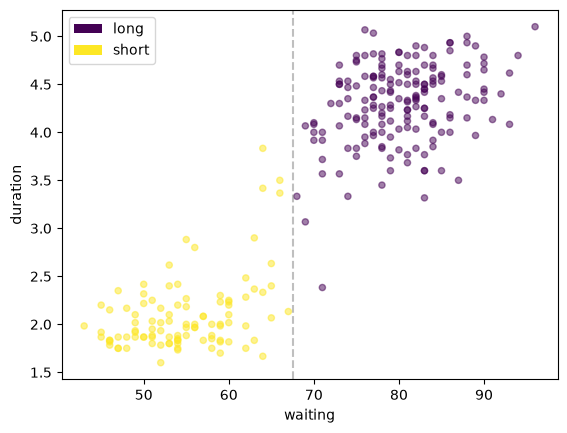

In [1099]:
geyser.plot.scatter(x='waiting', y='duration', alpha=.5, c='kind')
plt.gca().axvline(67.5, ls='--', color='gray', alpha=.5)
plt.show()

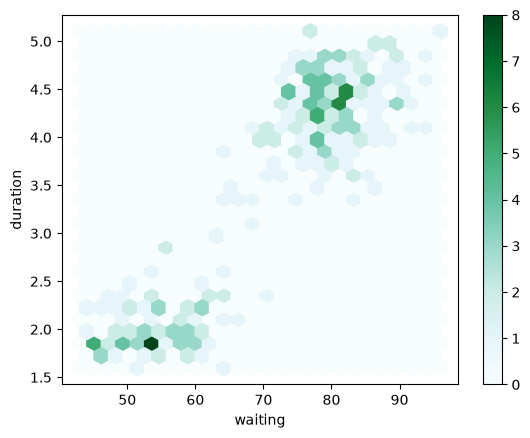

In [1103]:
geyser.plot.hexbin(x='waiting', y='duration', gridsize=25)
plt.show()

The feature `kind` appears to be an after the fact labeling of a clusters.

## Exercise

In [1067]:
exercise = sns.load_dataset('exercise')
exercise

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest
...,...,...,...,...,...,...
85,85,29,no fat,135,15 min,running
86,86,29,no fat,130,30 min,running
87,87,30,no fat,99,1 min,running
88,88,30,no fat,111,15 min,running


In [1068]:
exercise1 = exercise.copy()
exercise1['event_num'] = exercise.groupby('id').cumcount() + 1
exercise1

,Unnamed: 0,id,diet,pulse,time,kind,event_num
0,0,1,low fat,85,1 min,rest,1
1,1,1,low fat,85,15 min,rest,2
2,2,1,low fat,88,30 min,rest,3
3,3,2,low fat,90,1 min,rest,1
4,4,2,low fat,92,15 min,rest,2
...,...,...,...,...,...,...,...
85,85,29,no fat,135,15 min,running,2
86,86,29,no fat,130,30 min,running,3
87,87,30,no fat,99,1 min,running,1
88,88,30,no fat,111,15 min,running,2


In [1070]:
exercise1.kind.value_counts()

kind
rest       30
walking    30
running    30
Name: count, dtype: int64

In [1073]:
exercise.set_index(['id','time'])[['diet','pulse','kind']]

diet  pulse     kind
id time                           
1  1 min   low fat     85     rest
   15 min  low fat     85     rest
   30 min  low fat     88     rest
2  1 min   low fat     90     rest
   15 min  low fat     92     rest
...            ...    ...      ...
29 15 min   no fat    135  running
   30 min   no fat    130  running
30 1 min    no fat     99  running
   15 min   no fat    111  running
   30 min   no fat    150  running

[90 rows x 3 columns]

In [1077]:
exercise.value_counts(['diet','kind']).unstack()

kind,rest,walking,running
diet,,,
no fat,15,15,15
low fat,15,15,15
